In [ ]:
# CWRU Cross-Load Testing with Grad-CAM and LRP Explainability
# Adapted for your existing CNN model and folder structure


import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import cv2
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add pywt import
import pywt

# Reproducibility
SEED = 1
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# ============================================================================
# CONFIGURATION - ADJUST THESE PATHS
# ============================================================================
BASE_PATH = '/content/drive/MyDrive/BearingProject/CWRU/'

# Folder names for each load
LOAD_FOLDERS = {
    '1730': 'BearingData_CaseWestern_12K1730',  # 3HP
    '1750': 'BearingData_CaseWestern_12K1750',  # 2HP
    '1772': 'BearingData_CaseWestern_12K1772',  # 1HP
    '1797': 'BearingData_CaseWestern_12K1797'   # 0HP
}

# Your existing parameters
SAMPLE_LENGTH = 1600
IMAGE_SIZE = 40
OVERLAP = 0.5
NUM_CLASSES = 10  # Adjust based on your classes

# Training parameters
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 0.001

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_mat_file(filepath):
    """Load a single .mat file and extract DE time series"""
    try:
        mat_data = loadmat(filepath)
        # Find the DE (Drive End) key
        de_keys = [key for key in mat_data.keys() if 'DE_time' in key]
        if de_keys:
            return mat_data[de_keys[0]].flatten()
        # If no DE_time, try other keys
        for key in mat_data.keys():
            if not key.startswith('__') and isinstance(mat_data[key], np.ndarray):
                data = mat_data[key]
                if len(data.shape) <= 2:
                    return data.flatten()
        return None
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def segment_signal(signal_data, sample_length=1600, overlap=0.5):
    """Segment continuous signal into overlapping windows"""
    step = int(sample_length * (1 - overlap))
    segments = []

    for start in range(0, len(signal_data) - sample_length + 1, step):
        segment = signal_data[start:start + sample_length]
        segments.append(segment)

    return np.array(segments)

def load_data_from_folder(folder_path, num_samples_per_class=None):
    """
    Load all .mat files from a folder and create dataset

    Returns:
    --------
    X : numpy array of shape (n_samples, 1600)
    y : numpy array of labels
    file_mapping : dict mapping file names to labels
    """
    mat_files = sorted(glob.glob(os.path.join(folder_path, '*.mat')))

    if len(mat_files) == 0:
        print(f"Warning: No .mat files found in {folder_path}")
        return None, None, None

    print(f"Found {len(mat_files)} .mat files in {folder_path}")

    X_list = []
    y_list = []
    file_mapping = {}

    for label_idx, mat_file in enumerate(mat_files):
        filename = os.path.basename(mat_file)
        file_mapping[filename] = label_idx

        # Load and segment
        signal_data = load_mat_file(mat_file)
        if signal_data is not None:
            segments = segment_signal(signal_data, SAMPLE_LENGTH, OVERLAP)

            # Limit samples if specified
            if num_samples_per_class is not None:
                segments = segments[:num_samples_per_class]

            X_list.append(segments)
            y_list.append(np.full(len(segments), label_idx))

            print(f"  {filename}: {len(segments)} samples (label {label_idx})")

    if len(X_list) == 0:
        return None, None, None

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    # Shuffle
    shuffle_idx = np.random.permutation(len(X))
    X = X[shuffle_idx]
    y = y[shuffle_idx]

    return X, y, file_mapping

# ============================================================================
# SIGNAL TO IMAGE CONVERSION (YOUR EXISTING METHOD)
# ============================================================================

def cwt_to_image(signal_1d, image_size=40):
    """
    Convert 1D signal to 2D image using Continuous Wavelet Transform
    This should match your existing preprocessing
    """
    scales = np.arange(1, image_size + 1)

    # Compute CWT using pywt
    coefficients, _ = pywt.cwt(signal_1d, scales, 'gaus1') # Changed 'mexican' to 'gaus1'

    # Resize to desired image size
    if coefficients.shape != (image_size, image_size):
        coefficients = cv2.resize(coefficients,
                                 (image_size, image_size),
                                 interpolation=cv2.INTER_LINEAR)

    # Normalize to [0, 1]
    coefficients = (coefficients - coefficients.min()) / (coefficients.max() - coefficients.min() + 1e-8)

    return coefficients

def convert_batch_to_images(signals, image_size=40):
    """Convert batch of signals to images"""
    images = []
    for signal_1d in signals:
        image = cwt_to_image(signal_1d, image_size)
        images.append(image)

    images = np.array(images)
    images = np.expand_dims(images, axis=-1)  # Add channel dimension
    return images

# ============================================================================
# YOUR EXISTING CNN MODEL (KEEP AS IS)
# ============================================================================

def build_cnn_model(input_shape=(40, 40, 1), num_classes=10):
    """
    Your existing CNN architecture - DO NOT CHANGE
    This should match your working model
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Conv Block 1
        tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_16'),
        tf.keras.layers.MaxPooling2D((2, 2), padding='same'),

        # Conv Block 2
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_17'),
        tf.keras.layers.MaxPooling2D((2, 2), padding='same'),

        # Conv Block 3
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_18'),
        tf.keras.layers.MaxPooling2D((2, 2), padding='same'),

        # Conv Block 4
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv2d_19'),
        tf.keras.layers.MaxPooling2D((2, 2), padding='same'),

        # Fully connected layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

# ============================================================================
# GRAD-CAM IMPLEMENTATION
# ============================================================================

class GradCAM:
    """Grad-CAM for CNN visualization"""

    def __init__(self, model, last_conv_layer_name='conv2d_19'):
        self.model = model
        self.last_conv_layer_name = last_conv_layer_name

        # Ensure the model's input shape is defined
        if not self.model.built:
             # This assumes model has a first layer that can derive input_shape
            dummy_input_shape = (1,) + self.model.layers[0].input_shape[1:]
            self.model.build(dummy_input_shape)

        # Define a new input tensor that matches the model's input shape
        input_tensor_for_grad_model = tf.keras.Input(shape=self.model.input_shape[1:])

        x = input_tensor_for_grad_model
        conv_layer_output = None

        # Manually traverse the layers of the original model
        # to connect them to the new input tensor. This is more robust
        # for extracting intermediate outputs from Sequential models.
        for layer in self.model.layers:
            # Apply the layer to the current tensor 'x'
            x = layer(x)
            # If this is the last convolutional layer, store its output
            if layer.name == last_conv_layer_name:
                conv_layer_output = x

        # The final output of the model after passing through all layers
        model_final_output = x

        if conv_layer_output is None:
            raise ValueError(f"Convolutional layer '{last_conv_layer_name}' not found in the model.")

        # Create grad model using the new symbolic input and the extracted outputs
        self.grad_model = tf.keras.Model(
            inputs=input_tensor_for_grad_model,
            outputs=[conv_layer_output, model_final_output]
        )

    def compute_heatmap(self, image, class_idx=None):
        """
        Compute Grad-CAM heatmap

        Parameters:
        -----------
        image : numpy array (H, W, C)
        class_idx : int or None (None = predicted class)

        Returns:
        --------
        heatmap : numpy array (H, W)
        predicted_class : int
        """
        # Expand dimensions
        img_array = np.expand_dims(image, axis=0)

        # Compute gradients
        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(img_array)
            if class_idx is None:
                class_idx = tf.argmax(predictions[0])
            loss = predictions[:, class_idx]

        # Get gradients
        grads = tape.gradient(loss, conv_outputs)

        # Global average pooling
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        # Weight feature maps
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        # Normalize
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        heatmap = heatmap.numpy()

        # Resize to original image size
        heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

        return heatmap, int(class_idx)

    def overlay_heatmap(self, image, heatmap, alpha=0.4):
        """
        Overlay heatmap on original image
        """
        # Normalize image to [0, 255]
        img = (image.squeeze() * 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        # Apply colormap to heatmap using matplotlib
        cmap = plt.cm.get_cmap('jet') # Get the 'jet' colormap from matplotlib
        # Apply colormap to the normalized heatmap. Output is RGBA float (0-1)
        heatmap_rgba_float = cmap(heatmap)
        # Convert to RGB (0-255 uint8) and then to BGR for OpenCV
        heatmap_bgr = (heatmap_rgba_float[:, :, :3] * 255).astype(np.uint8)
        heatmap_bgr = cv2.cvtColor(heatmap_bgr, cv2.COLOR_RGB2BGR)

        # Overlay
        superimposed = cv2.addWeighted(img_bgr, 1 - alpha, heatmap_bgr, alpha, 0)

        return superimposed

# ============================================================================
# LRP IMPLEMENTATION
# ============================================================================

class LRP:
    """Layer-wise Relevance Propagation"""

    def __init__(self, model):
        self.model = model

    def compute_lrp(self, image, class_idx=None, epsilon=1e-7):
        """
        Compute LRP heatmap (simplified version using gradients)

        Parameters:
        -----------
        image : numpy array (H, W, C)
        class_idx : int or None

        Returns:
        --------
        relevance_map : numpy array (H, W)
        """
        # Forward pass
        img_array = np.expand_dims(image, axis=0)
        predictions = self.model.predict(img_array, verbose=0)

        if class_idx is None:
            class_idx = np.argmax(predictions[0])

        # Compute gradients (simplified LRP using gradient × input)
        with tf.GradientTape() as tape:
            img_tensor = tf.constant(img_array, dtype=tf.float32)
            tape.watch(img_tensor)
            preds = self.model(img_tensor)
            loss = preds[:, class_idx]

        grads = tape.gradient(loss, img_tensor)
        relevance_map = (img_tensor * grads).numpy()[0]

        # Process relevance map
        relevance_map = np.abs(relevance_map)
        relevance_map = relevance_map.sum(axis=-1)  # Sum across channels
        relevance_map = (relevance_map - relevance_map.min()) / (relevance_map.max() - relevance_map.min() + epsilon)

        return relevance_map, int(class_idx)

# ============================================================================
# CROSS-LOAD EXPERIMENT RUNNER
# ============================================================================

class CrossLoadExperiment:
    """Run cross-load experiments with explainability"""

    def __init__(self, base_path, load_folders):
        self.base_path = base_path
        self.load_folders = load_folders
        self.results = []

    def run_experiment(self, train_load, test_loads, exp_name,
                      num_samples_per_class=500, save_dir='./cross_load_results/'):
        """
        Run a cross-load experiment

        Parameters:
        -----------
        train_load : str
            Load ID for training (e.g., '1797')
        test_loads : list of str
            Load IDs for testing (e.g., ['1797', '1772', '1750', '1730'])
        exp_name : str
            Experiment name
        """
        print("\n" + "="*80)
        print(f"EXPERIMENT: {exp_name}")
        print(f"Training on: {train_load} RPM")
        print(f"Testing on: {', '.join(test_loads)} RPM")
        print("="*80)

        exp_dir = os.path.join(save_dir, exp_name)
        os.makedirs(exp_dir, exist_ok=True)

        # ========================================
        # LOAD TRAINING DATA
        # ========================================
        print("\n1. Loading TRAINING data...")
        train_folder = os.path.join(self.base_path, self.load_folders[train_load])
        X_train, y_train, train_file_mapping = load_data_from_folder(
            train_folder, num_samples_per_class
        )

        if X_train is None:
            print(f"Error: Could not load training data from {train_folder}")
            return None

        print(f"Training data shape: {X_train.shape}")
        print(f"Training labels: {np.bincount(y_train.astype(int))}")

        # ========================================
        # CONVERT TO IMAGES
        # ========================================
        print("\n2. Converting signals to images...")
        X_train_2d = convert_batch_to_images(X_train, IMAGE_SIZE)
        print(f"Training images shape: {X_train_2d.shape}")

        # Split for validation
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_train_2d, y_train, test_size=0.2, random_state=SEED, stratify=y_train
        )

        # One-hot encode
        num_classes = len(np.unique(y_train))
        y_train_oh = tf.keras.utils.to_categorical(y_train_split, num_classes)
        y_val_oh = tf.keras.utils.to_categorical(y_val_split, num_classes)

        # ========================================
        # BUILD AND TRAIN MODEL
        # ========================================
        print("\n3. Building and training model...")
        model = build_cnn_model(input_shape=X_train_2d[0].shape,
                               num_classes=num_classes)
        # Explicitly build the model to ensure its input is defined
        model.build(input_shape=(None,) + X_train_2d.shape[1:])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=20,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ModelCheckpoint(
                os.path.join(exp_dir, 'best_model.h5'),
                monitor='val_accuracy',
                save_best_only=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=10,
                min_lr=1e-6
            )
        ]

        history = model.fit(
            X_train_split, y_train_oh,
            validation_data=(X_val_split, y_val_oh),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        # Plot training history
        self.plot_training_history(history, exp_dir)

        # ========================================
        # TEST ON EACH LOAD
        # ========================================
        print("\n4. Testing on different loads...")
        test_results = {}

        for test_load in test_loads:
            print(f"\n   Testing on {test_load} RPM...")

            # Load test data
            test_folder = os.path.join(self.base_path, self.load_folders[test_load])
            X_test, y_test, test_file_mapping = load_data_from_folder(
                test_folder, num_samples_per_class
            )

            if X_test is None:
                print(f"   Warning: Could not load test data from {test_folder}")
                continue

            # Convert to images
            X_test_2d = convert_batch_to_images(X_test, IMAGE_SIZE)
            y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes)

            # Evaluate
            test_loss, test_acc = model.evaluate(X_test_2d, y_test_oh, verbose=0)
            print(f"   Test Accuracy on {test_load} RPM: {test_acc:.4f}")

            # Predictions
            y_pred = model.predict(X_test_2d, verbose=0)
            y_pred_classes = np.argmax(y_pred, axis=1)

            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred_classes)

            # Save results
            test_results[test_load] = {
                'accuracy': float(test_acc),
                'confusion_matrix': cm.tolist(),
                'file_mapping': test_file_mapping
            }

            # Plot confusion matrix
            self.plot_confusion_matrix(
                cm,
                f"Confusion Matrix - Test on {test_load} RPM",
                os.path.join(exp_dir, f'confusion_matrix_{test_load}.png')
            )

            # Generate explainability visualizations
            print(f"   Generating explainability visualizations for {test_load} RPM...")
            self.generate_explainability(
                model, X_test_2d, y_test, y_pred_classes,
                exp_dir, test_load, num_samples=3
            )

        # ========================================
        # SAVE RESULTS
        # ========================================
        import json
        results = {
            'experiment_name': exp_name,
            'train_load': train_load,
            'test_loads': test_loads,
            'train_file_mapping': train_file_mapping,
            'test_results': test_results,
            'timestamp': datetime.now().isoformat()
        }

        with open(os.path.join(exp_dir, 'results.json'), 'w') as f:
            json.dump(results, f, indent=4)

        self.results.append(results)

        print(f"\n\u2713 Experiment completed! Results saved to {exp_dir}")

        return model, results

    def plot_training_history(self, history, save_dir):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Accuracy
        ax1.plot(history.history['accuracy'], label='Train')
        ax1.plot(history.history['val_accuracy'], label='Validation')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Loss
        ax2.plot(history.history['loss'], label='Train')
        ax2.plot(history.history['val_loss'], label='Validation')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'training_history.png'),
                   dpi=300, bbox_inches='tight')
        plt.close()

    def plot_confusion_matrix(self, cm, title, save_path):
        """Plot confusion matrix"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(title)
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

    def generate_explainability(self, model, X_test, y_test, y_pred,
                            exp_dir, test_load, num_samples=3):

      gradcam = GradCAM(model)
      lrp = LRP(model)

      base_dir = os.path.join(exp_dir, f'explainability_{test_load}')
      correct_dir = os.path.join(base_dir, "correct")
      wrong_dir = os.path.join(base_dir, "misclassified")
      compare_dir = os.path.join(base_dir, "comparison")

      os.makedirs(correct_dir, exist_ok=True)
      os.makedirs(wrong_dir, exist_ok=True)
      os.makedirs(compare_dir, exist_ok=True)

      classes = np.unique(y_test)

      for cls in classes:

        # -------------------------------
        # Correct samples
        # -------------------------------
        correct_idx = np.where((y_test == cls) & (y_pred == cls))[0]
        wrong_idx = np.where((y_test == cls) & (y_pred != cls))[0]

        correct_idx = correct_idx[:num_samples]
        wrong_idx = wrong_idx[:num_samples]

        # -------------------------------
        # Generate correct examples
        # -------------------------------
        for i, idx in enumerate(correct_idx):
          img = X_test[idx]
          true_label = int(y_test[idx])
          pred_label = int(y_pred[idx])

          cam, _ = gradcam.compute_heatmap(img, pred_label)
          overlay = gradcam.overlay_heatmap(img, cam)
          lrp_map, _ = lrp.compute_lrp(img, pred_label)

          fig, ax = plt.subplots(1, 4, figsize=(16, 4))

          ax[0].imshow(img.squeeze(), cmap='gray')
          ax[0].set_title(f"Original\nClass {true_label}")
          ax[0].axis("off")

          ax[1].imshow(cam, cmap='jet')
          ax[1].set_title(f"Grad-CAM\nPred {pred_label}")
          ax[1].axis("off")

          ax[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
          ax[2].set_title("Grad-CAM Overlay")
          ax[2].axis("off")

          ax[3].imshow(lrp_map, cmap='hot')
          ax[3].set_title("LRP")
          ax[3].axis("off")

          plt.tight_layout()
          plt.savefig(os.path.join(correct_dir, f"class_{cls}_correct_{i+1}.png"),
                        dpi=300, bbox_inches='tight')
          plt.close()

        # -------------------------------
        # Generate misclassified examples
        # -------------------------------
        for i, idx in enumerate(wrong_idx):

          img = X_test[idx]
          true_label = int(y_test[idx])
          pred_label = int(y_pred[idx])

          cam, _ = gradcam.compute_heatmap(img, pred_label)
          overlay = gradcam.overlay_heatmap(img, cam)
          lrp_map, _ = lrp.compute_lrp(img, pred_label)

          fig, ax = plt.subplots(1, 4, figsize=(16, 4))

          ax[0].imshow(img.squeeze(), cmap='gray')
          ax[0].set_title(f"Original\nTrue {true_label}\nPred {pred_label}")
          ax[0].axis("off")

          ax[1].imshow(cam, cmap='jet')
          ax[1].set_title("Grad-CAM")
          ax[1].axis("off")

          ax[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
          ax[2].set_title("Grad-CAM Overlay")
          ax[2].axis("off")

          ax[3].imshow(lrp_map, cmap='hot')
          ax[3].set_title("LRP")
          ax[3].axis("off")

          plt.tight_layout()
          plt.savefig(os.path.join(wrong_dir,
                                     f"true_{true_label}_pred_{pred_label}_wrong_{i+1}.png"),dpi=300, bbox_inches='tight')

          plt.close()

        # -------------------------------
        # SIDE-BY-SIDE COMPARISON
        # -------------------------------
        if len(correct_idx) > 0 and len(wrong_idx) > 0:

            c_idx = correct_idx[0]
            w_idx = wrong_idx[0]

            img_c = X_test[c_idx]
            img_w = X_test[w_idx]

            true_c = int(y_test[c_idx]); pred_c = int(y_pred[c_idx])
            true_w = int(y_test[w_idx]); pred_w = int(y_pred[w_idx])

            cam_c, _ = gradcam.compute_heatmap(img_c, pred_c)
            cam_w, _ = gradcam.compute_heatmap(img_w, pred_w)

            ov_c = gradcam.overlay_heatmap(img_c, cam_c)
            ov_w = gradcam.overlay_heatmap(img_w, cam_w)

            lrp_c, _ = lrp.compute_lrp(img_c, pred_c)
            lrp_w, _ = lrp.compute_lrp(img_w, pred_w)

            fig, ax = plt.subplots(2, 3, figsize=(14, 8))

            # Correct row
            ax[0,0].imshow(img_c.squeeze(), cmap='gray'); ax[0,0].axis("off")
            ax[0,0].set_title(f"Correct:\nTrue={true_c}, Pred={pred_c}")

            ax[0,1].imshow(cam_c, cmap='jet'); ax[0,1].axis("off")
            ax[0,1].set_title("Grad-CAM (Correct)")

            ax[0,2].imshow(lrp_c, cmap='hot'); ax[0,2].axis("off")
            ax[0,2].set_title("LRP (Correct)")

            # Wrong row
            ax[1,0].imshow(img_w.squeeze(), cmap='gray'); ax[1,0].axis("off")
            ax[1,0].set_title(f"Wrong:\nTrue={true_w}, Pred={pred_w}")

            ax[1,1].imshow(cam_w, cmap='jet'); ax[1,1].axis("off")
            ax[1,1].set_title("Grad-CAM (Wrong)")

            ax[1,2].imshow(lrp_w, cmap='hot'); ax[1,2].axis("off")
            ax[1,2].set_title("LRP (Wrong)")

            plt.tight_layout()
            plt.savefig(os.path.join(compare_dir, f"class_{cls}_comparison.png"),
                        dpi=300, bbox_inches='tight')
            plt.close()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    # Initialize experiment runner
    runner = CrossLoadExperiment(BASE_PATH, LOAD_FOLDERS)

    # ========================================================================
    # EXPERIMENT 1: Train on 1797 (0HP), Test on All
    # ========================================================================
    model1, results1 = runner.run_experiment(
        train_load='1797',
        test_loads=['1797', '1772', '1750', '1730'],
        exp_name='Exp1_Train_1797_Test_All',
        num_samples_per_class=500
    )

    # ========================================================================
    # EXPERIMENT 2: Train on 1772 (1HP), Test on 1797 (0HP)
    # ========================================================================
    model2, results2 = runner.run_experiment(
        train_load='1772',
        test_loads=['1797'],
        exp_name='Exp2_Train_1772_Test_1797',
        num_samples_per_class=500
    )

    # ========================================================================
    # EXPERIMENT 3: Train on 1730 (3HP), Test on All
    # ========================================================================
    model3, results3 = runner.run_experiment(
        train_load='1730',
        test_loads=['1797', '1772', '1750', '1730'],
        exp_name='Exp3_Train_1730_Test_All',
        num_samples_per_class=500
    )

    print("\n" + "="*80)
    print("ALL CROSS-LOAD EXPERIMENTS COMPLETED!")
    print("="*80)



EXPERIMENT: Exp1_Train_1797_Test_All
Training on: 1797 RPM
Testing on: 1797, 1772, 1750, 1730 RPM

1. Loading TRAINING data...
Found 10 .mat files in /content/drive/MyDrive/BearingProject/CWRU/BearingData_CaseWestern_12K1797
  105.mat: 150 samples (label 0)
  118.mat: 152 samples (label 1)
  130.mat: 151 samples (label 2)
  169.mat: 151 samples (label 3)
  185.mat: 151 samples (label 4)
  197.mat: 151 samples (label 5)
  209.mat: 151 samples (label 6)
  222.mat: 151 samples (label 7)
  234.mat: 152 samples (label 8)
  97.mat: 303 samples (label 9)
Training data shape: (1663, 1600)
Training labels: [150 152 151 151 151 151 151 151 152 303]

2. Converting signals to images...
Training images shape: (1663, 40, 40, 1)

3. Building and training model...
Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1856 - loss: 2.1898

42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1868 - loss: 2.1861 - val_accuracy: 0.4324 - val_loss: 1.6950 - learning_rate: 0.0010
Epoch 2/200
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3803 - loss: 1.6684

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3822 - loss: 1.6625 - val_accuracy: 0.5105 - val_loss: 1.2976 - learning_rate: 0.0010
Epoch 3/200
37/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4769 - loss: 1.3536

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4786 - loss: 1.3484 - val_accuracy: 0.5676 - val_loss: 1.2286 - learning_rate: 0.0010
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5327 - loss: 1.2332 - val_accuracy: 0.5135 - val_loss: 1.2118 - learning_rate: 0.0010
Epoch 5/200
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5322 - loss: 1.2235

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5329 - loss: 1.2214 - val_accuracy: 0.6997 - val_loss: 0.9336 - learning_rate: 0.0010
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6111 - loss: 1.0240 - val_accuracy: 0.6937 - val_loss: 0.8412 - learning_rate: 0.0010
Epoch 7/200
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6444 - loss: 0.9614

...

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9175 - loss: 0.2204 - val_accuracy: 0.9462 - val_loss: 0.1606 - learning_rate: 0.0010
Epoch 19/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9337 - loss: 0.1795 - val_accuracy: 0.9247 - val_loss: 0.2100 - learning_rate: 0.0010
Epoch 20/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9291 - loss: 0.1752 - val_accuracy: 0.9328 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 21/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9478 - loss: 0.1724 - val_accuracy: 0.9247 - val_loss: 0.2013 - learning_rate: 0.0010
Epoch 22/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9482 - loss: 0.1600 - val_accuracy: 0.9355 - val_loss: 0.1941 - learning_rate: 0.0010
Epoch 23/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9414 - loss: 0.1565 - val_accuracy: 0.9409 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 24/200
40/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9458 - loss: 0.1501

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9469 - loss: 0.1475 - val_accuracy: 0.9516 - val_loss: 0.1759 - learning_rate: 0.0010
Epoch 25/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9502 - loss: 0.1489 - val_accuracy: 0.9328 - val_loss: 0.1866 - learning_rate: 0.0010
Epoch 26/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9501 - loss: 0.1412 - val_accuracy: 0.9489 - val_loss: 0.1372 - learning_rate: 0.0010
Epoch 27/200
41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9622 - loss: 0.1123

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9619 - loss: 0.1121 - val_accuracy: 0.9624 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 28/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9699 - loss: 0.0886 - val_accuracy: 0.9462 - val_loss: 0.1351 - learning_rate: 0.0010
Epoch 29/200
40/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9799 - loss: 0.0710

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9789 - loss: 0.0727 - val_accuracy: 0.9677 - val_loss: 0.1028 - learning_rate: 0.0010
Epoch 30/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9786 - loss: 0.0666 - val_accuracy: 0.9543 - val_loss: 0.1467 - learning_rate: 0.0010
Epoch 31/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9747 - loss: 0.0816 - val_accuracy: 0.9677 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 32/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9749 - loss: 0.0698 - val_accuracy: 0.9651 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 33/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9837 - loss: 0.0444 - val_accuracy: 0.9624 - val_loss: 0.1155 - learning_rate: 0.0010
Epoch 34/200
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9806 - loss: 0.0511

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9808 - loss: 0.0510 - val_accuracy: 0.9812 - val_loss: 0.0775 - learning_rate: 0.0010
Epoch 35/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9888 - loss: 0.0363 - val_accuracy: 0.9731 - val_loss: 0.0829 - learning_rate: 0.0010
Epoch 36/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9850 - loss: 0.0395 - val_accuracy: 0.9731 - val_loss: 0.0815 - learning_rate: 0.0010
Epoch 37/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9906 - loss: 0.0264 - val_accuracy: 0.9651 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 38/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9914 - loss: 0.0299 - val_accuracy: 0.9704 - val_loss: 0.1069 - learning_rate: 0.0010
Epoch 39/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9928 - loss: 0.0385 - val_accuracy: 0.9785 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 40/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9834 - loss: 0.0577 - val_acc


CROSS-LOAD EXPERIMENT ANALYSIS

📁 Loading experiment results...
✅ Loaded 3 experiment results

CROSS-LOAD PERFORMANCE MATRIX

Accuracy values for each train-test combination:
Test Load   1730 RPM  1750 RPM  1772 RPM  1797 RPM
Train Load                                        
1730 RPM      0.9952    0.0005    0.0022    0.0036
1772 RPM         NaN       NaN       NaN    0.6747
1797 RPM      0.0075    0.7550    0.7487    0.9747

------------------------------------------------------------
PERFORMANCE DEGRADATION ANALYSIS
------------------------------------------------------------

📊 Model trained on 1797 RPM:
   Baseline (same load): 0.9747 (97.47%)
   Test on 1730 RPM: 0.0075 (0.75%) | Degradation: 96.72%
   Test on 1750 RPM: 0.7550 (75.50%) | Degradation: 21.98%
   Test on 1772 RPM: 0.7487 (74.87%) | Degradation: 22.61%

📊 Model trained on 1772 RPM:
   Test on 1797 RPM: 0.6747 (67.47%)

📊 Model trained on 1730 RPM:
   Baseline (same load): 0.9952 (99.52%)
   Test on 1750 RPM: 0.0005 

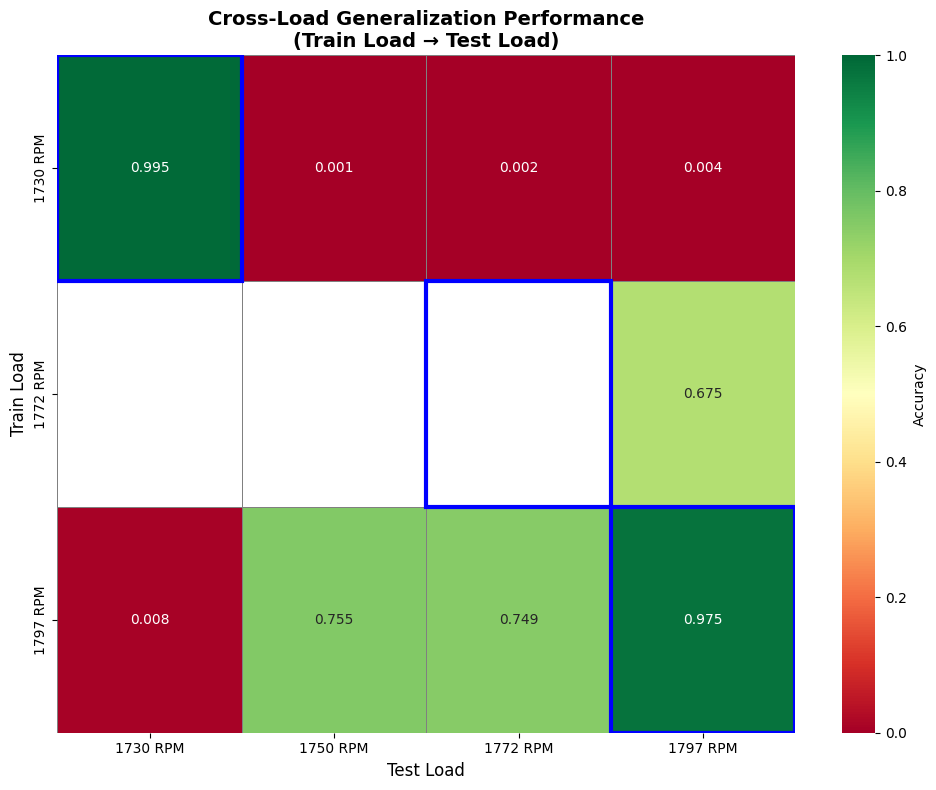


✅ Heatmap saved to: ./cross_load_results/cross_load_heatmap.png


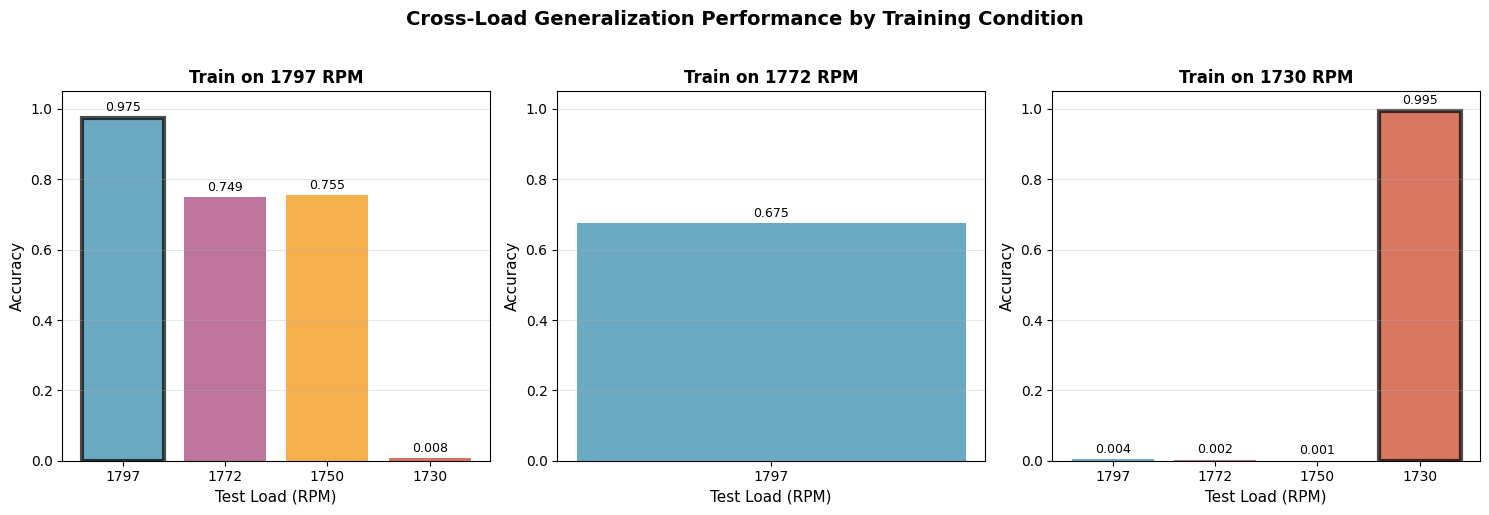

✅ Degradation curves saved to: ./cross_load_results/degradation_curves.png

STATISTICAL SUMMARY

📈 Overall Statistics:
   Mean accuracy (all tests): 0.4625
   Std deviation (all tests): 0.4218
   Min accuracy: 0.0005
   Max accuracy: 0.9952

🎯 Same-Load Performance:
   Mean accuracy: 0.9850
   Std deviation: 0.0102

🔄 Cross-Load Performance:
   Mean accuracy: 0.3132
   Std deviation: 0.3584
   Mean degradation: 67.18%

✅ LaTeX table saved to: ./cross_load_results/results_table.tex

✅ Analysis summary saved to: ./cross_load_results/analysis_summary.txt

ANALYSIS COMPLETE!


In [ ]:
# Add this code at the end of your main script after all experiments complete
# Or run it separately after your experiments finish

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

def load_experiment_results(results_dir='./cross_load_results/'):
    """Load all experiment results from JSON files"""
    results = []
    experiments = [
        'Exp1_Train_1797_Test_All',
        'Exp2_Train_1772_Test_1797',
        'Exp3_Train_1730_Test_All'
    ]

    for exp_name in experiments:
        json_path = os.path.join(results_dir, exp_name, 'results.json')
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                results.append(json.load(f))

    return results

def create_summary_table(results_list):
    """Create a summary table of cross-load performance"""
    data = []
    for result in results_list:
        train = result['train_load']
        for test, metrics in result['test_results'].items():
            data.append({
                'Train Load': f"{train} RPM",
                'Test Load': f"{test} RPM",
                'Accuracy': metrics['accuracy'],
                'Same Load': train == test
            })

    df = pd.DataFrame(data)

    # Create pivot table
    pivot_df = df.pivot_table(index='Train Load', columns='Test Load', values='Accuracy')

    print("\n" + "="*60)
    print("CROSS-LOAD PERFORMANCE MATRIX")
    print("="*60)
    print("\nAccuracy values for each train-test combination:")
    print(pivot_df.round(4))

    # Calculate degradation
    print("\n" + "-"*60)
    print("PERFORMANCE DEGRADATION ANALYSIS")
    print("-"*60)

    for result in results_list:
        train_load = result['train_load']
        print(f"\n📊 Model trained on {train_load} RPM:")

        # Get baseline (same load) accuracy if available
        baseline_acc = None
        if train_load in result['test_results']:
            baseline_acc = result['test_results'][train_load]['accuracy']
            print(f"   Baseline (same load): {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")

        # Calculate degradation for other loads
        for test_load, metrics in sorted(result['test_results'].items()):
            if test_load != train_load:
                acc = metrics['accuracy']
                if baseline_acc:
                    degradation = (baseline_acc - acc) * 100
                    print(f"   Test on {test_load} RPM: {acc:.4f} ({acc*100:.2f}%) | Degradation: {degradation:.2f}%")
                else:
                    print(f"   Test on {test_load} RPM: {acc:.4f} ({acc*100:.2f}%)")

    return df, pivot_df

def plot_cross_load_heatmap(pivot_df, save_path='./cross_load_results/cross_load_heatmap.png'):
    """Create a heatmap visualization of cross-load performance"""
    plt.figure(figsize=(10, 8))

    # Create heatmap with annotations
    sns.heatmap(pivot_df,
                annot=True,
                fmt='.3f',
                cmap='RdYlGn',
                vmin=0, vmax=1,
                cbar_kws={'label': 'Accuracy'},
                linewidths=0.5,
                linecolor='gray')

    plt.title('Cross-Load Generalization Performance\n(Train Load → Test Load)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Test Load', fontsize=12)
    plt.ylabel('Train Load', fontsize=12)

    # Highlight diagonal (same load testing)
    ax = plt.gca()
    for i in range(min(len(pivot_df), len(pivot_df.columns))):
        if pivot_df.index[i].split()[0] in [col.split()[0] for col in pivot_df.columns]:
            j = [col.split()[0] for col in pivot_df.columns].index(pivot_df.index[i].split()[0])
            rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='blue', lw=3)
            ax.add_patch(rect)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Heatmap saved to: {save_path}")

def plot_degradation_curves(results_list, save_path='./cross_load_results/degradation_curves.png'):
    """Plot performance degradation curves for each training condition"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    load_order = ['1797', '1772', '1750', '1730']  # 0HP to 3HP
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

    for idx, result in enumerate(results_list):
        if idx >= 3:  # Only plot first 3 experiments
            break

        train_load = result['train_load']
        ax = axes[idx]

        # Prepare data
        test_loads = []
        accuracies = []

        for load in load_order:
            if load in result['test_results']:
                test_loads.append(load)
                accuracies.append(result['test_results'][load]['accuracy'])

        # Plot
        x_pos = range(len(test_loads))
        bars = ax.bar(x_pos, accuracies, color=colors[:len(test_loads)], alpha=0.7)

        # Highlight training load
        train_idx = test_loads.index(train_load) if train_load in test_loads else -1
        if train_idx >= 0:
            bars[train_idx].set_edgecolor('black')
            bars[train_idx].set_linewidth(3)

        # Formatting
        ax.set_xlabel('Test Load (RPM)', fontsize=11)
        ax.set_ylabel('Accuracy', fontsize=11)
        ax.set_title(f'Train on {train_load} RPM', fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(test_loads)
        ax.set_ylim([0, 1.05])
        ax.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar, acc in zip(bars, accuracies):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Cross-Load Generalization Performance by Training Condition',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Degradation curves saved to: {save_path}")

def calculate_statistics(results_list):
    """Calculate and display statistical summary"""
    print("\n" + "="*60)
    print("STATISTICAL SUMMARY")
    print("="*60)

    all_accuracies = []
    same_load_accuracies = []
    cross_load_accuracies = []

    for result in results_list:
        train_load = result['train_load']
        for test_load, metrics in result['test_results'].items():
            acc = metrics['accuracy']
            all_accuracies.append(acc)

            if train_load == test_load:
                same_load_accuracies.append(acc)
            else:
                cross_load_accuracies.append(acc)

    print(f"\n📈 Overall Statistics:")
    print(f"   Mean accuracy (all tests): {np.mean(all_accuracies):.4f}")
    print(f"   Std deviation (all tests): {np.std(all_accuracies):.4f}")
    print(f"   Min accuracy: {np.min(all_accuracies):.4f}")
    print(f"   Max accuracy: {np.max(all_accuracies):.4f}")

    if same_load_accuracies:
        print(f"\n🎯 Same-Load Performance:")
        print(f"   Mean accuracy: {np.mean(same_load_accuracies):.4f}")
        print(f"   Std deviation: {np.std(same_load_accuracies):.4f}")

    if cross_load_accuracies:
        print(f"\n🔄 Cross-Load Performance:")
        print(f"   Mean accuracy: {np.mean(cross_load_accuracies):.4f}")
        print(f"   Std deviation: {np.std(cross_load_accuracies):.4f}")
        print(f"   Mean degradation: {(np.mean(same_load_accuracies) - np.mean(cross_load_accuracies))*100:.2f}%")

def generate_latex_table(pivot_df, save_path='./cross_load_results/results_table.tex'):
    """Generate LaTeX table for paper inclusion"""
    latex = pivot_df.round(4).to_latex()

    with open(save_path, 'w') as f:
        f.write("% Cross-Load Generalization Results\n")
        f.write("% Generated: " + datetime.now().isoformat() + "\n\n")
        f.write(latex)

    print(f"\n✅ LaTeX table saved to: {save_path}")

# ============================================================================
# MAIN ANALYSIS EXECUTION
# ============================================================================

if __name__ == '__main__':
    print("\n" + "="*60)
    print("CROSS-LOAD EXPERIMENT ANALYSIS")
    print("="*60)

    # Load results
    print("\n📁 Loading experiment results...")
    results = load_experiment_results()

    if not results:
        print("❌ No results found! Make sure experiments have completed.")
    else:
        print(f"✅ Loaded {len(results)} experiment results")

        # Create summary table
        df, pivot_df = create_summary_table(results)

        # Generate visualizations
        print("\n📊 Generating visualizations...")
        plot_cross_load_heatmap(pivot_df)
        plot_degradation_curves(results)

        # Calculate statistics
        calculate_statistics(results)

        # Generate LaTeX table
        generate_latex_table(pivot_df)

        # Save summary to text file
        summary_path = './cross_load_results/analysis_summary.txt'
        with open(summary_path, 'w') as f:
            f.write("="*60 + "\n")
            f.write("CROSS-LOAD EXPERIMENT ANALYSIS SUMMARY\n")
            f.write("Generated: " + datetime.now().isoformat() + "\n")
            f.write("="*60 + "\n\n")

            f.write("Performance Matrix:\n")
            f.write(pivot_df.round(4).to_string())
            f.write("\n\n")

            for result in results:
                f.write(f"\nExperiment: {result['experiment_name']}\n")
                f.write(f"Train Load: {result['train_load']} RPM\n")
                for test, metrics in result['test_results'].items():
                    f.write(f"  Test {test}: {metrics['accuracy']:.4f}\n")

        print(f"\n✅ Analysis summary saved to: {summary_path}")
        print("\n" + "="*60)
        print("ANALYSIS COMPLETE!")
        print("="*60)

In [ ]:
def compute_explainability_metrics(grad_cam_maps, lrp_maps, labels, predictions):
    """
    Quantify explainability patterns to correlate with model performance
    """
    metrics = {}

    # 1. Attention Consistency Score (ACS)
    # Measures how similar attention patterns are within same class
    def attention_consistency(maps, labels):
        consistency_scores = []
        for class_id in np.unique(labels):
            class_maps = maps[labels == class_id]
            if len(class_maps) > 1:
                # Compute pairwise similarity
                similarities = []
                for i in range(len(class_maps)-1):
                    for j in range(i+1, len(class_maps)):
                        sim = np.corrcoef(class_maps[i].flatten(),
                                         class_maps[j].flatten())[0,1]
                        similarities.append(sim)
                consistency_scores.append(np.mean(similarities))
        return np.mean(consistency_scores)

    # 2. Attention Dispersion Index (ADI)
    # Measures spread of attention (compact vs scattered)
    def attention_dispersion(attention_map):
        # Calculate spatial entropy
        flat = attention_map.flatten()
        flat = flat / flat.sum()  # Normalize to probability
        entropy = -np.sum(flat * np.log(flat + 1e-10))
        return entropy

    # 3. Edge Activation Ratio (EAR)
    # Quantifies reliance on edge artifacts
    def edge_activation_ratio(attention_map, border_size=5):
        h, w = attention_map.shape
        edge_sum = np.sum(attention_map[:border_size, :]) + \
                   np.sum(attention_map[-border_size:, :]) + \
                   np.sum(attention_map[:, :border_size]) + \
                   np.sum(attention_map[:, -border_size:])
        total_sum = np.sum(attention_map)
        return edge_sum / (total_sum + 1e-10)

    # 4. Cross-Load Attention Similarity (CLAS)
    # Measures if same fault has similar attention across loads
    def cross_load_similarity(maps_train_load, maps_test_load, labels):
        similarities = []
        for class_id in np.unique(labels):
            train_class = maps_train_load[labels == class_id]
            test_class = maps_test_load[labels == class_id]
            if len(train_class) > 0 and len(test_class) > 0:
                sim = np.corrcoef(train_class.mean(0).flatten(),
                                 test_class.mean(0).flatten())[0,1]
                similarities.append(sim)
        return np.mean(similarities)

    metrics['consistency'] = attention_consistency(grad_cam_maps, labels)
    metrics['dispersion'] = np.mean([attention_dispersion(m) for m in grad_cam_maps])
    metrics['edge_ratio'] = np.mean([edge_activation_ratio(m) for m in grad_cam_maps])

    return metrics